<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Run Cellpose-SAM

Adapted from Marius Pachitariu, Michael Rariden, Carsen Stringer and the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki)

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

In [1]:
# Check GPU and instantiate model - will download weights.
import numpy as np
from cellpose import models, core, io, plot, utils
from cellpose_functions import *
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
import cv2 as cv 
import tifffile as tf
%matplotlib inline
from natsort import natsorted
from skimage import exposure, filters, morphology, transform

#Check if GPU access


## Check if the GPU is correctly loaded
Also now can choose model in cpsam 4.2


In [2]:
pretrained_model = "cpsam_v2"
pretrained_models =["cpsam_v2", "cpsam", "cpdino", "cpdino-vitb"]

def load_model(pretrained_model="cpsam_v2", gpu=True):
    """
    Loads a cellpose model, uses cp_sam by default but can specify any model
    Parameters:
          pretrained_model (None or str): the name of the pretrained model specified, by default assumes cpsam
          gpu (bool, optional): specify whether or not to use gpu, true by default

    Returns:
          model (Cellpose.model object): the model loaded
    """
    io.logger_setup() #run this to get printing of progress
    if gpu == True:
        if core.use_gpu() == False:
            raise ImportError("No GPU access, change your runtime")

    model = models.CellposeModel(pretrained_model=pretrained_model, gpu=True)
    return model

load_model()

[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:30:03,762 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-07-22 11:30:03,762 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:30:03,830 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:30:03,831 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:30:03,831 [core INFO] >>>> using GPU (CUDA)
2026-07-22 11:30:04,882 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam_v2


## Set the input directory with your images:

In [3]:
# Inputs
#dirfolder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegSubset_2"  # "/mnt/bigdisk1/AllieSpangaro/IF_HAP1_October2019/max_projections"
dirfolder = ("/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ")


dirfolder = Path(dirfolder)
if not dirfolder.exists():
    raise FileNotFoundError("directory does not exist")

# *** To pick a folder: dirfolder = Path("/path/to/your/folder") ***
dirlist = [
    p
    for p in dirfolder.rglob("*")
    if p.is_dir()
    and "masks" not in p.name
    and "flows" not in p.name
    and "plots" not in p.name
    and "testmasks" not in p.name
    and "testplots" not in p.name
    and "testflows" not in p.name
    and "train" not in p.name
    and "trainmasks" not in p.name
    and "trainplots" not in p.name
    and "trainflows" not in p.name
]
# dirlist = [dir for dir in dirfolder.glob("*")]
display(dirlist)

[PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20240326_rep02'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250328_rep05'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20241112_rep04'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20241018_rep03'),
 PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20240313_rep01')]

In [4]:
# *** To view files: change to your image extension ***
image_ext = ".tif"
nchannels = 4

# files = natsorted(
#     [
#         f for f in dirfolder.glob("*" + image_ext) if "_masks" not in f.name and "_flows" not in f.name
#     ]
# )

# if len(files) == 0:
#     raise FileNotFoundError(
#         "no image files found, did you specify the correct folder and extension?"
#     )
# else:
#     print(f"{len(files)} images in folder:")

# for f in files:
#     print(f.name)

# Recursively run through a folder of image files one-by-one

In [ ]:
def run_cellpose_on_folder_list(dirlist, pretrained_model="cpsam_v2", v2=True, test_all_models=False, pretrained_models=pretrained_models, save_plots=False, done_folders=[]):
    for dir in dirlist:
        maskdir = dir / "testmasks"
        maskdir.mkdir(exist_ok=True)
        #nchannels = 4
        if dir.name in done_folders:#the folders that are already done
            continue
        else:
            if "rep04" in dir.name:
                nchannels = 3
            else:
                nchannels = 4
            print("writing to: " + str(maskdir))
            files = load_sorted_directory_list(dir)
            if test_all_models:
                for model in pretrained_models:
                    print(f"Testing model: {model}")
                    save_mask_folder_v2(files,maskdir,nchannels=nchannels, pretrained_model=model, show_model_name=True, save_plots=save_plots)
                    #save_mask_folder(files,maskdir,v2=v2, nchannels=nchannels, pretrained_model=model, show_model_name=True, save_plots=save_plots)
            else:
                #save_mask_folder(files,maskdir,v2=v2, nchannels=nchannels, pretrained_model=pretrained_model, save_plots=save_plots)
                save_mask_folder_v2(files,maskdir,nchannels=nchannels, pretrained_model=pretrained_model, show_model_name=True, save_plots=save_plots)

done_folders=[]#["rep01", "rep02", "rep06", "rep04","rep07","rep03"]
run_cellpose_on_folder_list(dirlist,v2=True, test_all_models=False, save_plots=False, done_folders=done_folders)


writing to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250410_rep06/testmasks
[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:30:05,676 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-07-22 11:30:05,677 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:30:05,677 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:30:05,678 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:30:05,678 [core INFO] >>>> using GPU (CUDA)
2026-07-22 11:30:06,657 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam_v2


  0%|          | 1/3120 [00:02<2:27:51,  2.84s/it]

2026-07-22 11:30:12,420 [dynamics INFO] No cell pixels found.


  0%|          | 2/3120 [00:05<2:24:00,  2.77s/it]

2026-07-22 11:30:15,078 [dynamics INFO] No cell pixels found.


...

 57%|█████▋    | 1648/2880 [2:07:07<1:54:23,  5.57s/it]

2026-07-22 17:27:33,965 [dynamics INFO] No cell pixels found.


 59%|█████▊    | 1685/2880 [2:09:48<1:23:47,  4.21s/it]

2026-07-22 17:30:16,502 [dynamics INFO] No cell pixels found.


 60%|█████▉    | 1724/2880 [2:12:48<1:26:12,  4.47s/it]

[INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

[Note:] remember https://pmc.ncbi.nlm.nih.gov/articles/PMC8560386/#sec5 for mitochondria

### set up the correct order for the image filenames - sort by location first, then channel
these functions moved to cellpose_functions


## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [9]:
index = 1
img_files_test = load_sorted_directory_list(dirlist[index])
maskdir = dirlist[index] / "a_testmasks"
maskdir.mkdir(exist_ok=True)

#display(img_files_test)
print(maskdir)
files = img_files_test 
#files = sort_files(dir, image_ext)
grouped_files = group_files_by_channel_dict(files)
display(grouped_files)
#print_files(files)
print_grouped_files(grouped_files)
#print(f"\nSet name: {get_image_set_name(grouped_files[0], 1)}")
#print(f"Plate location: {get_location_code(files[0].name)}")

print(f"Number of channels: {get_nchannels(files)}")

/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/a_testmasks


{'rep07_r02c01f01': [PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch1-r02c01f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch2-r02c01f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch3-r02c01f01.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch4-r02c01f01.tif')],
 'rep07_r02c01f02': [PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch1-r02c01f02.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch2-r02c01f02.tif'),
  PosixPath('/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/MAX_ch3-r02c01f02.tif'),
  PosixPath('/mn


 Group 1 of 2880: rep07_r02c01f01
 MAX_ch1-r02c01f01.tif
 MAX_ch2-r02c01f01.tif
 MAX_ch3-r02c01f01.tif
 MAX_ch4-r02c01f01.tif

 Group 2 of 2880: rep07_r02c01f02
 MAX_ch1-r02c01f02.tif
 MAX_ch2-r02c01f02.tif
 MAX_ch3-r02c01f02.tif
 MAX_ch4-r02c01f02.tif

 Group 3 of 2880: rep07_r02c01f03
 MAX_ch1-r02c01f03.tif
 MAX_ch2-r02c01f03.tif
 MAX_ch3-r02c01f03.tif
 MAX_ch4-r02c01f03.tif

 Group 4 of 2880: rep07_r02c01f04
 MAX_ch1-r02c01f04.tif
 MAX_ch2-r02c01f04.tif
 MAX_ch3-r02c01f04.tif
 MAX_ch4-r02c01f04.tif

 Group 5 of 2880: rep07_r02c01f05
 MAX_ch1-r02c01f05.tif
 MAX_ch2-r02c01f05.tif
 MAX_ch3-r02c01f05.tif
 MAX_ch4-r02c01f05.tif

 Group 6 of 2880: rep07_r02c01f06
 MAX_ch1-r02c01f06.tif
 MAX_ch2-r02c01f06.tif
 MAX_ch3-r02c01f06.tif
 MAX_ch4-r02c01f06.tif

 Group 7 of 2880: rep07_r02c01f07
 MAX_ch1-r02c01f07.tif
 MAX_ch2-r02c01f07.tif
 MAX_ch3-r02c01f07.tif
 MAX_ch4-r02c01f07.tif

 Group 8 of 2880: rep07_r02c01f08
 MAX_ch1-r02c01f08.tif
 MAX_ch2-r02c01f08.tif
 MAX_ch3-r02c01f08.tif
 MAX_ch

### Load in and preprocess the images 
#### For Channel Selection
If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to None. Choosing multiple channels may produce segmentaiton of all the structures in the image.

In [12]:
def get_image_set_without_modifications(single_grouped_files_by_channel, selected_channels=[], nchannels=None):
    """
    Load an image set given file paths for a single image set; load images from a single element of the list made by the `group_files_by_channel` function
    Parameters:
          single_grouped_files_by_channel (list of Path objects): list of file paths grouped by channel and ordered by platemap location
          selected_channels (list of int): a list with the desired channels to use/process (1-indexed)
          nchannels (int or None): the number of channels. Assumes based on length of first element otherwise
    Returns:
          image_set (list of 2D arrays): a list of 2D arrays representing the loaded single-channel grayscale images
    """
    #can choose to load only a subset of channels if desired, otherwise will load all channels
    if selected_channels == []:
        nchannels = len(single_grouped_files_by_channel)
    else:
        nchannels = len(selected_channels)
    # load the images from the channels - skip ch3 at position 2 as DAPI is always the last channel
   
    image_set = []
    for i in range(nchannels):
        image_channel = io.imread(single_grouped_files_by_channel[i])
        image_set.append(image_channel)
    return image_set


def stack_images_with_histogram_matching(img_set, selected_channels=[1, 2, 4], reference_channel=2):
    """
    Stack and preprocess multiple grayscale images given a list of single-channel grayscale images given a referene channel for matching
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
           selected channels (list of int): a list with the desired channels to use/process (1-indexed)
           reference_channel (int, optional): the channel to use as a reference for histogram matching, 2 by default
    Returns:
          multi_channel_image (3D array): a 3D array containing the preprocessed grayscale images
    """
    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    reference_channel_index = reference_channel - 1
    img_stack = []
    for i in range(len(img_set)):
        if i + 1 in selected_channels:
            channel = img_set[i]
            if i != reference_channel_index:
                channel = exposure.match_histograms(
                    channel, img_set[reference_channel_index], channel_axis=None
                )
            img_stack.append(channel)

    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image

def img_preprocessing_test(
    img_set, selected_channels=[1,2,3,4]
):
    """
    Preprocess a grayscale image given an list of single-channel grayscale images with historam equalization, and median filter smoothing and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
    Returns:
          multi_channel_image (3D array): a 3D array containing the preprocessed grayscale images
    """
    from skimage import filters, data, morphology,restoration, exposure

    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    for chnum in selected_channels:
        # footprint = morphology.disk(5)
        channel = img_set[chnum - 1]
        # # #do a rolling ball background subtraction
        # kernel = None#restoration.ellipsoid_kernel((25, 25), 0.1)
        # radius = 10
        # background = restoration.rolling_ball(
        #     channel, kernel=kernel, radius=radius
        # )
        # channel = channel - background
        #channel = img_01_normalization(channel)
        channel = exposure.equalize_adapthist(channel, kernel_size=100, clip_limit=0.02)
        channel = filters.median(channel, morphology.disk(2))
        img_stack.append(channel)

    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image


def img_preprocessing_hap1(img_set, selected_channels=[1, 2, 3, 4], nucleus_channel = 3, mode = "retain"):
    """
    Preprocess a grayscale image given an list of single-channel grayscale images with historam equalization, and median filter smoothing and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
           selected channels (list of int): a list with the desiered channels to use/process (1-indexed)
           mode (str, "retain" or "remove): whether to keep the other channels downstream or discard them
    Returns:
          multi_channel_image (3D array): a 3D array containing the preprocessed grayscale images
    """
    from skimage import exposure, filters, morphology

    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    if mode == "retain":
        for i, channel in enumerate(img_set):
            if i + 1 in selected_channels:
                # footprint = morphology.disk(5)
                channel = img_01_normalization(channel)
                # don't apply histogram equalization to nuc; will bring out background too much
                if i+1 != nucleus_channel:
                    channel = exposure.equalize_adapthist(
                        channel, kernel_size=100, clip_limit=0.01
                    )
                #channel = filters.gaussian(channel, sigma=2)
                channel = filters.median(channel, morphology.disk(2))
                img_stack.append(channel)
            else:
                channel = img_01_normalization(channel)
                img_stack.append(channel)
    elif mode == "remove":
        for chnum in selected_channels:
            # footprint = morphology.disk(5)
            channel = img_set[chnum - 1]
            # footprint = morphology.disk(5)
            channel = img_01_normalization(channel)
            channel = exposure.equalize_adapthist(channel, kernel_size=100, clip_limit=0.02)
            #channel = filters.gaussian(channel, sigma=2)
            channel = filters.median(channel, morphology.disk(2))
            img_stack.append(channel)
    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image

def get_multichannel_img_normalized(img_set, selected_channels=[1, 2, 3, 4]):
    """
    Create a multichannel grayscale image given an list of single-channel grayscale images and stack the image together
    Parameters:
           img_set (list of 2D arrays): a list of 2D arrays representing grayscale images
    Returns:
          multi_channel_image (3D array): an array containing the grayscale images with channel in the third dimension
    """
    # ch1,ch2,ch3 = io.imread(files[0]), io.imread(files[1]), io.imread(files[3])
    # channels = [ch1, ch2, ch3]
    img_stack = []
    for chnum in selected_channels:
        # footprint = morphology.disk(5)
        channel = img_set[chnum - 1]
        channel = img_01_normalization(channel)
        img_stack.append(channel)

    multi_channel_image = np.stack(img_stack, axis=-1)
    return multi_channel_image


In [30]:
def spline_order(interpolation_method: str) -> int:
    """Determine interpolation order from method.
    Args:
        interpolation_method (str): The interpolation method to use. Must be one of 'nearest', 'bilinear', or 'bicubic'.
    Returns:
        int: The interpolation order.
    """
    interpolation_method = interpolation_method.lower()
    if interpolation_method == "nearest":
        return 0

    elif interpolation_method == "bilinear":
        return 1

    elif interpolation_method == "bicubic":
        return 3

    else:
        raise ValueError(
            f"Invalid interpolation method: {interpolation_method}. Must be one of 'nearest', 'bilinear', or 'bicubic'."
        )


def preprocessing_for_cell_segmentation(
    orig_img,
    composite_channels=[1, 2],
    nucleus_channel=3,
    rescale_factor=0.15,
    interpolation_method="bicubic",
    anti_aliasing=False,
):
    """
    Preprocess a grayscale image of the cell channels, run cellpose on the image, and return the predicted masks
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           nucleus_channel (int, optional): the channel to use for the nuclear channel, 3 by default
    Returns:
          preprocessed_img (2D or 3D array): the preprocessed grayscale image for cell segmentation
    """
    # combine the specified channels to help cellpose out a bit
    gfp = orig_img[:, :, composite_channels[0] - 1]
    rfp = orig_img[:, :, composite_channels[1] - 1]
    # save the specified nuclear channel for later
    dapi = orig_img[:, :, nucleus_channel - 1]
    # add the channels and normalize intensity
    img_combo = gfp + rfp
    img_combo = img_01_normalization(img_combo)
    img_combo = exposure.equalize_adapthist(
        img_combo, kernel_size=128, clip_limit=0.01, nbins=256
    )
    dapi = img_01_normalization(dapi)
    dapi = exposure.equalize_adapthist(
        dapi, kernel_size=128, clip_limit=0.01, nbins=256
    )
    # denoise / smooth with gaussian kernel
    img_combo = filters.gaussian(img_combo, sigma=2)
    dapi = filters.gaussian(dapi, sigma=10)

    # stack the images
    preprocessed_img = np.stack([img_combo, dapi], axis=-1)
    # rescale the images for speed
    preprocessed_img = transform.rescale(
        preprocessed_img,
        scale=rescale_factor,
        order=spline_order(interpolation_method),
        mode="symmetric",
        channel_axis=-1,
        anti_aliasing=anti_aliasing,
    )
    return preprocessed_img

def preprocessing_for_nuclei_segmentation(
    orig_img,
    nucleus_channel=3,
    gaussian_sigma=2,
    rescale_factor=0.25,
    interpolation_method="bicubic",
    anti_aliasing=False,
    use_adaptive_histogram_equalization=True,
    use_white_tophat=True,
    use_median_filter=False,
    use_closing=True,
    use_unsharp_mask=True,
):
    """
    Preprocess a grayscale image of the nuclear channel, run cellpose on the image, and return the predicted masks
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           nucleus_channel (int, optional): the channel to use for the nuclear channel, 3 by default
           gaussian_sigma (float, optional): the sigma for the gaussian kernel used to smooth the image, 2 by default
           rescale_factor (float, optional): the factor to rescale the image by, 0.25 by default
           interpolation_method (str, optional): the interpolation method to use for rescaling, 'bicubic' by default
              anti_aliasing (bool, optional): flag whether to use anti-aliasing when rescaling, false by default
              use_white_tophat (bool, optional): flag whether to use white top-hat filtering to remove background, true by default
              use_unsharp_mask (bool, optional): flag whether to use unsharp masking to sharpen the image, false by default

    Returns:
          preprocessed_img (2D or 3D array): the preprocessed grayscale image for nuclear segmentation
    """
    dapi = orig_img[:, :, nucleus_channel - 1]
    dapi = img_01_normalization(dapi)
    if use_adaptive_histogram_equalization:
        dapi = exposure.equalize_adapthist(
            dapi, kernel_size=100, clip_limit=0.01, nbins=256
        )
    if use_median_filter:
        dapi = filters.median(dapi, morphology.disk(2))
    if use_white_tophat:
        bg2 = morphology.white_tophat(dapi, morphology.disk(3))
        dapi = dapi - bg2
    if use_closing:
        dapi = morphology.closing(dapi, morphology.disk(2.5))
        dapi = img_01_normalization(dapi)
    if use_unsharp_mask:
        # sharpen image and improve outline (radius is the gaussian kernel)
        dapi = filters.unsharp_mask(dapi, radius=gaussian_sigma, amount=1)
    else:
        dapi = filters.gaussian(dapi, sigma=gaussian_sigma)

    # rescale the images for speed
    preprocessed_img = transform.rescale(
        dapi,
        scale=rescale_factor,
        order=spline_order(interpolation_method),
        mode="symmetric",
        anti_aliasing=anti_aliasing,
    )
    return preprocessed_img


def run_cellpose_segmentation(
    img,
    model,
    show_plot=True,
    flow_threshold=0.4,
    cellprob_threshold=0,
    tile_norm_blocksize=100,
    diameter=None,
    min_size=100,
    max_size_frac=0.80,  # keep masks up to 80% of image size
    niter=1000,
    dilate_radius=0,
    fill_holes=True,
    show_image_preprocessing=False,
    save_plots=False,
    plot_dir="",
    save_name="cell_segmentation_result",
):
    """
    Run cellpose-SAM on a grayscale multichannel cell image and return the predicted masks.
    Trained on cells ranging from 7.5-120 pixels, so rescale accordingly
    Parameters:
            img (2D or 3D array): grayscale image to be segmented by cellpose. ideally preprocessed already
            model (Cellpose.model): the cellpose model used for segmentation
            show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
            show_image_preprocessing (bool, optional): flag whether to show the preprocessed image
            flow_threshold (float, optional): the flow threshold for cellpose, (from original 0.4 default). Down for more stringent, up for more lenient
            cellprob_threshold (float, optional): the cell probability threshold for cellpose, 0 by default (from original 0 default).
            tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
            diameter (int or None, optional): the diameter for cellpose, 60 as experimentally determined, but None by default
            min_size (int, optional): the minimum size of masks to keep, 100 pixels by default
            max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.85 by default
            niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
            masks (list of 2D or 3D arrays): the predicted masks from the cellpose model
    """
    if show_image_preprocessing:
        tf.imshow(img, cmap="plasma")

    masks, flows, styles = model.eval(
        img,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size,
    )
    if fill_holes:
        masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    if dilate_radius > 0:
        masks = utils.dilate_masks(masks, n_iter=dilate_radius)
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img, masks, flows[0])
        plt.tight_layout()
        if save_plots:
            save_dir = Path(f"{plot_dir}/segmentation_plots")
            Path.mkdir(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir.as_posix()}/{save_name}.png")
            # print(f"Saved plot to {save_dir.as_posix()}/{save_name}.png")
        else:
            plt.show()
    return masks

Set name:  rep07_r02c01f33


[array([[115, 117, 115, ..., 122, 122, 120],
        [110, 113, 115, ..., 122, 120, 119],
        [110, 113, 116, ..., 121, 117, 114],
        ...,
        [585, 517, 479, ..., 118, 125, 123],
        [605, 546, 487, ..., 120, 125, 121],
        [655, 608, 526, ..., 123, 121, 116]],
       shape=(2160, 2160), dtype=uint16),
 array([[ 328,  334,  335, ...,  133,  132,  128],
        [ 369,  358,  335, ...,  143,  137,  134],
        [ 373,  376,  357, ...,  141,  138,  135],
        ...,
        [ 914,  953, 1015, ...,  150,  148,  148],
        [ 977, 1041, 1133, ...,  156,  152,  157],
        [1092, 1180, 1324, ...,  155,  148,  150]],
       shape=(2160, 2160), dtype=uint16),
 array([[  139,   141,   137, ...,   140,   142,   145],
        [  147,   145,   143, ...,   148,   144,   144],
        [  155,   146,   142, ...,   143,   151,   143],
        ...,
        [ 9837,  9679,  9557, ...,   156,   155,   149],
        [11339, 11152, 11064, ...,   147,   154,   154],
        [12860

(2160, 2160, 3)


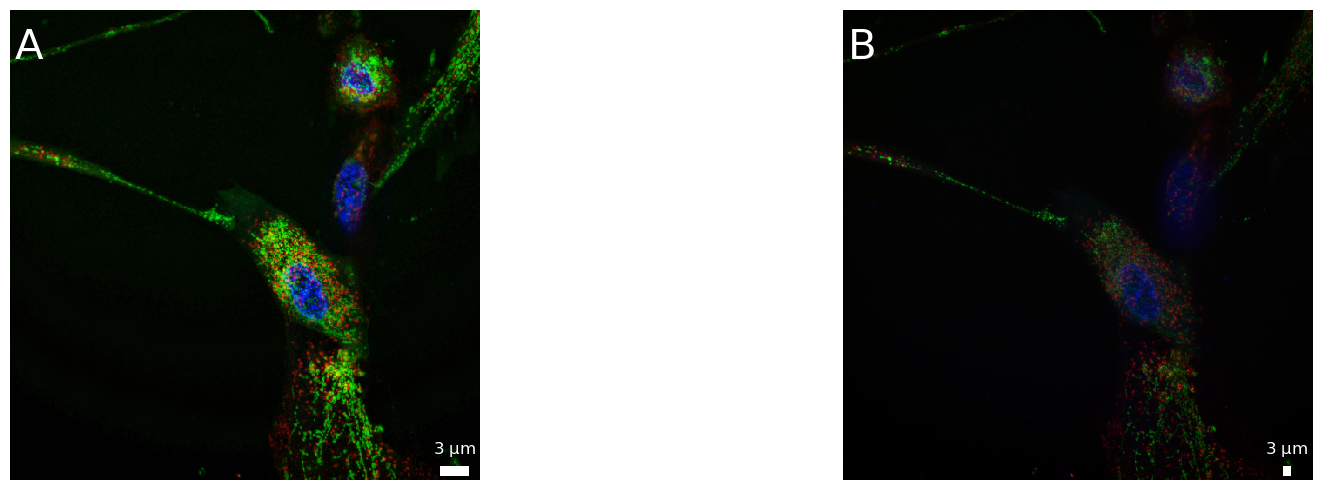

(324, 324, 2) (713, 713)


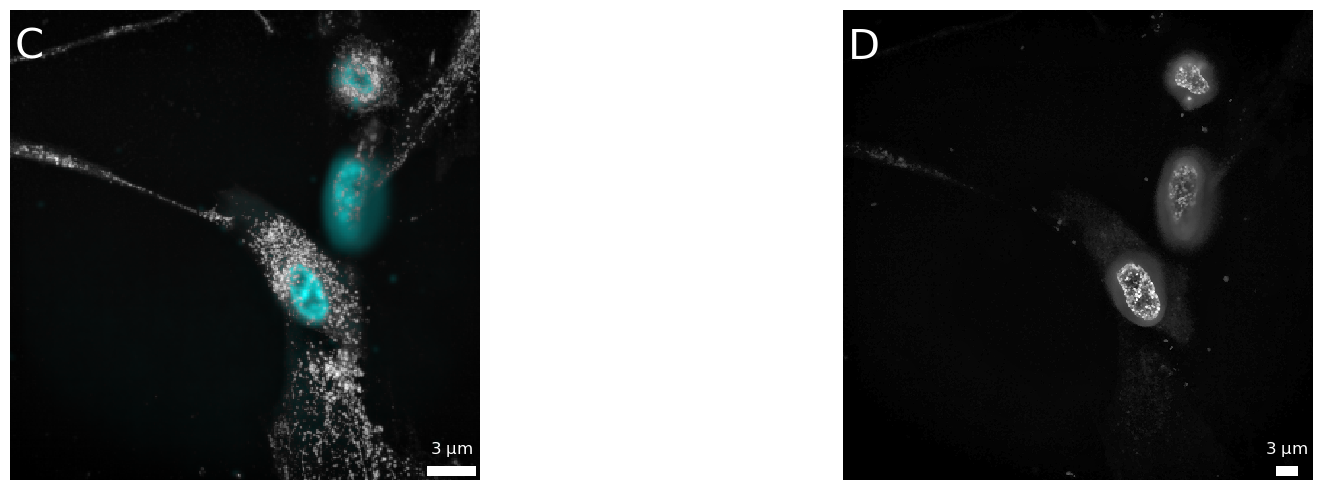

In [45]:
set_name = "rep07_r02c01f33"
image_set_index = 0
in_channels = get_image_set_without_modifications(grouped_files[set_name])
# set_name = get_image_set_name(grouped_files.values()[image_set_index])
print("Set name: ", set_name)
display(in_channels)
selected_channels = [1, 2, 4]

img_histogram_eq = stack_images_with_histogram_matching(
    in_channels, selected_channels=selected_channels, reference_channel=2
)

# img1_v2 = img_preprocessing_v2(in_channels)
# img2_v2 = img_rescaled(img1_v2, factor=0.25)

img1_v3 = img_preprocessing_test(in_channels, selected_channels)
img2_v3 = img_rescaled(img1_v3, factor=0.25)

cell_preprocessed = preprocessing_for_cell_segmentation(
    img_histogram_eq,
    composite_channels=[1,2],
    nucleus_channel=3,
    rescale_factor=0.15,
    interpolation_method="bicubic",
    anti_aliasing=False,
)
nucleus_preprocessed = preprocessing_for_nuclei_segmentation(
    img_histogram_eq,
    nucleus_channel=3,
    gaussian_sigma=2,
    rescale_factor=0.33,
    interpolation_method="bicubic",
    anti_aliasing=False,
    use_adaptive_histogram_equalization=True,
    use_white_tophat=True,
    use_median_filter=False,
    use_closing=True,
    use_unsharp_mask=True,
)

def microfilm_plot(
    image_set,
    cmaps=[
        "pure_red",
        "pure_green",
        "pure_blue",
    ],  # use these if the cmap library isn't working
    # cmaps = ["gray_r", "cyan", "magenta"],
    channel_names=["MitoTracker", "LAMP1", "DAPI"],
    channel_label_show=True,
    scalebar_unit_per_pix=0.09,
    scalebar_size_in_units=3,
    fig_scaling=5.0,
    label_text="",
    ax=None,
    save=False,
    save_path=None,
):
    """Plots a microfigure using the microfilm library with specified parameters.
    See https://guiwitz.github.io/microfilm/notebooks/create_plots.html
    Args:
        image_set (list or np.array): A list of 2D arrays or a 3D array of images to be plotted, with shape (height, width, channels).
        cmaps (list): A list of colormaps for each channel. Default is ['pure_red', 'pure_green', 'pure_blue'].
        channel_names (list): A list of names for each channel. Default is ["MitoTracker", "LAMP1", "DAPI"].
        scalebar_unit_per_pix (float): The size of each pixel in micrometers. Default is 0.09.
        scalebar_size_in_units (float): The size of the scalebar in micrometers. Default is 3.
        fig_scaling (float): Scaling factor for the figure  size. Default is 5.0.
        label_text (str): Text to be added as a label on the figure. Default is an empty string.
        ax (matplotlib.axes.Axes): An optional matplotlib axes object to plot
        save (bool): Whether to save the figure. Default is False.
        save_path (str): The path to save the figure if save is True. Default is None.
    Returns:
        microfigure: The microfigure object created by the microfilm library.
    """
    import skimage.io
    from microfilm import microplot

    # Note that this library expects a CXY format for the images, so we need to swap axes from XYC to CXY
    if isinstance(image_set, list):
        image_set = np.stack(image_set, axis=-1)
    image_set = np.swapaxes(image_set, 0, -1)
    try:
        correct_cmap = image_set.shape[0] == len(cmaps)
        if correct_cmap or cmaps is None or image_set.ndim != 3:
            pass
        else:
            raise ValueError(
                f"Number of channels in image_set ({image_set.shape[0]}) does not match number of colormaps provided ({len(cmaps)})."
            )
    except ValueError as e:
        print(f"ValueError: {e}")
        print("Using default colormaps instead.")
        cmaps = None
        channel_names = None
        
    # plt.figure(figsize=(10, 10))
    # don't show channel labels if an axis is provided or it will mess with formatting
    if ax:
        channel_label_show = False

    microfigure = microplot.microshow(
        images=image_set,
        cmaps=cmaps,
        flip_map=False,
        channel_label_show=channel_label_show,
        channel_names=channel_names,
        unit="um",
        scalebar_unit_per_pix=scalebar_unit_per_pix,
        scalebar_size_in_units=scalebar_size_in_units,
        scalebar_color="white",
        scalebar_font_size=12,
        fig_scaling=fig_scaling,
        ax=ax,
    )
    if label_text:
        microfigure.add_label(
            label_text=label_text, label_font_size=30, label_color="white"
        )
    if save and save_path is not None:
        microfigure.savefig(
            f"{save_path}/single.png", bbox_inches="tight", pad_inches=0, dpi=600
        )
    return microfigure


print(img_histogram_eq.shape)
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
fig1 = microfilm_plot(img2_v3, label_text="A", ax=axs[0])
fig2 = microfilm_plot(img_histogram_eq, label_text="B", ax=axs[1])
plt.tight_layout()
plt.show()
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
print(cell_preprocessed.shape, nucleus_preprocessed.shape)
fig3 = microfilm_plot(cell_preprocessed, cmaps=["gray", "pure_cyan"], label_text="C", ax=axs[0])
fig4 = microfilm_plot(nucleus_preprocessed, cmaps=["gray"], label_text="D", ax=axs[1])
plt.tight_layout()
plt.show()
# fig1 = microfilm_plot(img2_v3, label_text="A",channel_label_show=True,)
# tf.imshow((img_histogram_eq.max(axis=-1)), cmap="gray")
# tf.imshow((img_histogram_eq.max(axis=-1)), cmap="gray")
# tf.imshow(img_unprocessed_2)


### Run the original and updated mask code

In [15]:
def plot_result(image, background):
    fig, ax = plt.subplots(nrows=1, ncols=3)

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(background, cmap="gray")
    ax[1].set_title("Background")
    ax[1].axis("off")

    ax[2].imshow(image - background, cmap="gray")
    ax[2].set_title("Result")
    ax[2].axis("off")

    fig.tight_layout()
    
def segment_nuclei_v3(
    orig_img,
    model,
    nucleus_channel=3,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=0,
    tile_norm_blocksize=0,
    min_size=400,
    max_size_frac=0.4,
    diameter=None,
    niter=None,
    show_image_preprocessing=False,
    save_plots=False,
    plot_dir="",
    save_name="nuclei_segmentation_result",
):
    """
    Run cellpose-SAM on the nucleus channel from a multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           flow_threshold (float, optional): the flow threshold for cellpose, 0.5 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, 0 by default (from original 0 default). Up to be more stringent, down for a more lenient threshold
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, None by default
           min_size (int, optional): the minimum size of masks to keep, 400 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.4 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted nuclei masks from the cellpose model
    """
    from skimage import morphology, filters

    img = orig_img[:, :, nucleus_channel - 1]  # get the DAPI channel (and 0-index it)
    # img = img_01_normalization(img)

    # #do a rolling ball background subtraction
    # from skimage import data, restoration, util
    # background = restoration.rolling_ball(
    #     img, kernel=restoration.ellipsoid_kernel((25, 25), 0.1)
    # )
    # img = img - background
    # img = img_01_normalization(img)
    # # plot_result(img, background)
    # # plt.show()
    # img = filters.gaussian(img, sigma=1)

    # remove speckle-shaped autofluor
    bg2 = morphology.white_tophat(img, morphology.disk(3))
    img = img - bg2
    img = morphology.closing(img, morphology.disk(2.5))

    # sharpen image and improve outline (radius is the gaussian kernel)
    img = img_01_normalization(img)
    img = filters.gaussian(img, sigma=2)
    if show_image_preprocessing:
        tf.imshow(img, cmap="plasma")
    masks, flows, styles = model.eval(
        img,
        batch_size=64,
        diameter=diameter,
        niter=niter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
    )
    # dilate before removing the ones touching edges to catch the stragglers
    masks = utils.dilate_masks(masks, n_iter=1)
    masks_removed_edges = utils.remove_edge_masks(masks)
    masks_removed_edges = utils.fill_holes_and_remove_small_masks(
        masks_removed_edges, min_size=min_size
    )
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img, masks_removed_edges, flows[0])
        plt.tight_layout()
        if save_plots:
            save_dir = Path(f"{plot_dir}/segmentation_plots")
            Path.mkdir(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir.as_posix()}/{save_name}.png")
            print(f"Saved plot to {save_dir.as_posix()}/{save_name}.png")
        plt.show()
    return masks_removed_edges

def segment_cell_v3(
    img,
    model,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=-1,
    tile_norm_blocksize=100,
    diameter=None,
    min_size=500,
    max_size_frac=0.70,  # keep masks up to 70% of image size
    niter=1000,
    show_image_preprocessing=False,
    save_plots=False,
    plot_dir="",
    save_name="cell_segmentation_result",
):
    """
    Run cellpose-SAM on a grayscale multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           show_image_preprocessing (bool, optional): flag whether to show the preprocessed image
           flow_threshold (float, optional): the flow threshold for cellpose, 0.6 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, -1 by default (from original 0 default).
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, 60 as experimentally determined, but None by default
           min_size (int, optional): the minimum size of masks to keep, 500 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.85 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted masks from the cellpose model
    """
    from skimage import filters, morphology, exposure

    gfp = img[:, :, 0]  # combine the ch1 and ch2 images to help cellpose out a bit
    rfp = img[:, :, 1]
    dapi = img[:, :, 2]  # save ch3 for later

    img_combo = gfp + rfp
    img_combo = img_01_normalization(img_combo)
    # tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    img_combo = filters.gaussian(img_combo, sigma=1)
    # Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)

    # stack the images
    img_selected_channels = np.stack([img_combo, dapi], axis=-1)
    if show_image_preprocessing:
        tf.imshow(img_selected_channels, cmap="plasma")
    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size,
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        if save_plots:
            save_dir = Path(f"{plot_dir}/segmentation_plots")
            Path.mkdir(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir.as_posix()}/{save_name}.png")
            print(f"Saved plot to {save_dir.as_posix()}/{save_name}.png")
        plt.show()
    return masks

def segment_cell_hap1(
    img,
    model,
    selected_channels = [1,2,3,4],
    nucleus_channel = 3,
    show_plot=True,
    flow_threshold=0.4,
    cellprob_threshold=0,
    tile_norm_blocksize=100,
    diameter=None,
    min_size=200,
    max_size_frac=0.4,  # keep masks up to 70% of image size
    niter=None,
):
    """
    Run cellpose-SAM on a grayscale multichannel cell image and return the predicted masks
    Designed for a 2160x2160 image rescaled to 1/4 of original size
    Parameters:
           img (2D or 3D array): grayscale image to be segmented by cellpose
           model (Cellpose.model): the cellpose model used for segmentation
           show_plot (bool, optional): flag whether to show a plot of the predicted mask flow
           flow_threshold (float, optional): the flow threshold for cellpose, 0.4 by default (from original 0.4 default). Down for more stringent, up for more lenient
           cellprob_threshold (float, optional): the cell probability threshold for cellpose, from original 0 default.
           tile_norm_blocksize (int, optional): the tile normalization blocksize for cellpose, 100 by default. Generally between 100-200; 0 to turn off
           diameter (int or None, optional): the diameter for cellpose, 60 as experimentally determined on MRC, but None by default
           min_size (int, optional): the minimum size of masks to keep, 200 pixels by default
           max_size_frac (float, optional): the maximum size of masks to keep as a fraction of the image size, 0.4 by default
           niter (int or None, optional): the number of iterations for cellpose, None by default
    Returns:
          masks (list of 2D or 3D arrays): the predicted masks from the cellpose model
    """
    from skimage import filters, morphology, exposure

    channels_to_add_list = []
    try:
        for chnum in selected_channels:  
            zeroindex_chnum = chnum-1
            if chnum == nucleus_channel:
                continue
            else:
                ch = img[:, :, zeroindex_chnum]
                channels_to_add_list.append(ch)
        #stack everything in the list (excludes nuclei channel)
        segment_image_pre = np.stack(channels_to_add_list, axis=-1)
    except IndexError as e:
        print(
            f"Error: you selected {len(selected_channels)} channels, when your image only has {np.shape(img)[-1]} channels"
        )
        raise e
    if len(selected_channels) > 2: 
        segment_image = np.sum(segment_image_pre, axis=-1)
    else:
        segment_image = channels_to_add_list[0]
     
    # now we have nuclei seperated from the cyto segment image    
    segment_image = img_01_normalization(segment_image)
    nuc_image = img[:, :, nucleus_channel-1]
    # tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    segment_image = filters.gaussian(segment_image, sigma=1)
    # Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)
    # stack the images
    img_selected_channels = np.stack([segment_image, nuc_image], axis=-1)

    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size,
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks


[GUI INFO] : WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:24:34,423 [io INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2026-07-22 11:24:34,423 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.6.0+cu124
2026-07-22 11:24:34,423 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:24:34,423 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-22 11:24:34,423 [core INFO] >>>> using GPU (CUDA)
2026-07-22 11:24:35,202 [models INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam_v2


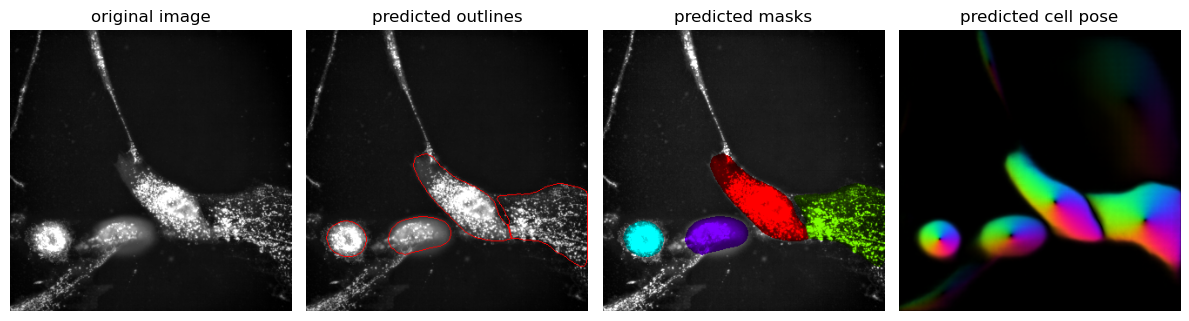

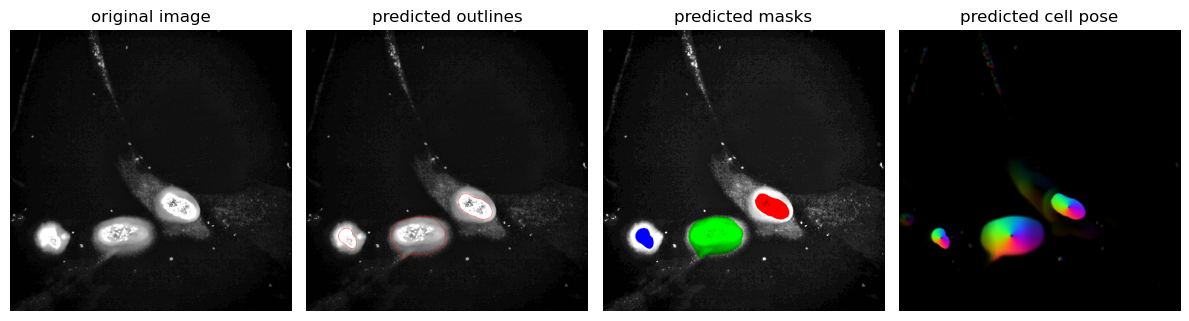

/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20250501_rep07/a_testmasks


In [46]:
#img = img2_v3
pretrained_model = "cpsam_v2"
model = load_model(pretrained_model=pretrained_model, gpu=True)

plot_dir = ""
save_name_nuc = ""
save_name_cell = ""
save_plots = False
if save_plots:
    plot_dir = Path(f"{maskdir}/segmentation_plots")
    Path.mkdir(plot_dir, exist_ok=True)
    save_name_nuc = f"{set_name}_nuclei_{pretrained_model}_segmentation_result"
    save_name_cell = f"{set_name}_cell_{pretrained_model}_segmentation_result"


cell_masks = run_cellpose_segmentation(
    cell_preprocessed,
    model,
    #show_image_preprocessing=True,
    diameter=None,
    cellprob_threshold=0,
    flow_threshold=0.4,
    save_plots=save_plots,
    plot_dir=plot_dir,
    save_name=save_name_cell,
)
nuc_masks = run_cellpose_segmentation(
    nucleus_preprocessed,
    model,
    #show_image_preprocessing=True,
    diameter=None,
    cellprob_threshold=0,
    flow_threshold=0.4,
    save_plots=save_plots,
    plot_dir=plot_dir,
    save_name=save_name_nuc,
)
# cell_v2_masks = segment_cell_v2(img2_v2,model)
# nuc_v2_masks = segment_nuclei_v2(img2_v2, model)

print(maskdir)

save_masks(
    set_name,
    cell_masks,
    outdir=maskdir,
    image_ext=image_ext,
    mask_type="cell_" + pretrained_model,
)
save_masks(
    set_name,
    nuc_masks,
    outdir=maskdir,
    image_ext=image_ext,
    mask_type="nuclei_" + pretrained_model,
)


In [ ]:
def find_row_col_field_string(img_set_name):
    import re

    rowcol_pattern = r"r(\d{1,2})c(\d{1,2})f(\d{1,2})"  # Matches "RX" where X is the replicate number (placeholder for now)
    match = re.search(rowcol_pattern, img_set_name)
    if match:
        row_metadata = int(match.group(1))
        col_metadata = int(match.group(2))
        field_metadata = int(match.group(3))
        return f'r{str(row_metadata).rjust(2, "0")}c{str(col_metadata).rjust(2, "0")}f{str(field_metadata).rjust(2, "0")}'
    else:
        return ""

def process_segment_save_img(in_channels, selected_channels, maskdir, set_name, nucleus_channel=3, image_ext=".tif"):
    img_pre = img_preprocessing_hap1(in_channels, selected_channels)
    img = img_rescaled(img_pre, factor=0.25)
    cell_masks = segment_cell_hap1(
        img, model, selected_channels=selected_channels, nucleus_channel=nucleus_channel, show_plot=False
    )
    nuc_masks = segment_nuclei_v3(img, model, nucleus_channel=nucleus_channel, show_plot=False)
    print(maskdir)
    save_masks(set_name, cell_masks, outdir=maskdir, image_ext=image_ext, mask_type="cell")
    save_masks(set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei")
    
def load_mask_list(dir, image_ext=".tif"):
    """
    Sort the list of masks 
    Parameters:
          dir (Path object or str): the directory containing the images
          image_ext (str, optional): the image extension, tif by default
    Returns:
          files (list of Path objects): the list of files sorted by location and channel
    """
    if not dir.exists():
        raise FileNotFoundError("directory does not exist")
    try:
        files = [f for f in dir.glob("*" + image_ext) if "_masks" in f.name and "_flows" not in f.name and "SUM" not in f.name]
    except IndexError as e:
        print(f"{e}, empty list, returning []")
        return []
    if len(files) == 0:
        return []
    else:
        return files
    
def iterate_dirlist(dirlist, model, image_ext=".tif", skip_existing = True):
    for dir in dirlist:
        maskdir = Path.joinpath(dir,"testmasks")
        maskdir.mkdir(exist_ok=True)
        # get this list if I want to skip existing masks
        mask_files = load_mask_list(maskdir) 
        print(mask_files)
        if mask_files == []:
            continue
        #now get the file list
        files = load_sorted_directory_list(dir)
        grouped_files = group_files_by_channel(files)
        for image_set_index,file in enumerate(grouped_files):
            set_coords = find_row_col_field_string(file[0].name)
            print(set_coords)
            #skip files that were already processed
            if skip_existing and mask_files:
                if set_coords in [mfiles.name for mfiles in mask_files]:
                    continue
                else:
                    in_channels = load_image_set_hap1(grouped_files[image_set_index])
                    set_name = get_image_set_name(grouped_files[image_set_index])
                    process_segment_save_img(in_channels, selected_channels, maskdir, set_name)
            else:
                in_channels = load_image_set_hap1(grouped_files[image_set_index])
                set_name = get_image_set_name(grouped_files[image_set_index])
                process_segment_save_img(in_channels,selected_channels,maskdir, set_name)
           
            
iterate_dirlist(dirlist, model, image_ext=".tif")

In [ ]:
maskdir = dir / "testmasksss"
print(maskdir.exists())

### Cells to make modifications to the existning preprocessing code before running the model

In [ ]:
# img = io.imread(files[0])
img = img2
def segment_cell_tweaking(
    img,
    model,
    show_plot=True,
    flow_threshold=0.6,
    cellprob_threshold=-1,
    tile_norm_blocksize=100,
    diameter=60,
    min_size=500,
    max_size_frac=0.85,  # keep masks up to 70% of image size
    niter=1000,
):
    from skimage import filters, morphology, exposure

    gfp = img[:, :, 0]  # combine the ch1 and ch2 images to help cellpose out a bit
    rfp = img[:, :, 1]
    dapi = img[:, :, 2]  # save ch3 for later

    img_combo = gfp + rfp
    img_combo = img_01_normalization(img_combo)
    #tf.imshow(img_combo, cmap="viridis")
    # smooth image and improve outline (sigma is the gaussian kernel)
    img_combo = filters.gaussian(img_combo, sigma=1)
    #Can also use unsharp mask, but it tends to chop the outlines too short img_combo = filters.unsharp_mask(img_combo, radius=0.5, amount=2)

    # stack the images
    img_selected_channels = np.stack([img_combo, dapi], axis=-1)

    masks, flows, styles = model.eval(
        img_selected_channels,
        batch_size=64,
        niter=niter,
        diameter=diameter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
        min_size=min_size
    )
    masks = utils.fill_holes_and_remove_small_masks(masks, min_size=min_size)
    masks = utils.dilate_masks(masks, n_iter=2)
    print(utils.size_distribution(masks))
    # plot if true
    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks


def segment_nuclei_tweaking(
    orig_img,
    model,
    show_plot=True,
    flow_threshold=0.5,
    cellprob_threshold=1,
    tile_norm_blocksize=100,
    min_size=400,
    max_size_frac=0.4,
    diameter=None,
    niter=None,
):
    from skimage import morphology, filters

    img = orig_img[:, :, 2]  # get the DAPI channel

    # remove speckle-shaped autofluor
    bg2 = morphology.white_tophat(img, morphology.disk(3))
    img = img - bg2
    img = morphology.closing(img, morphology.disk(2.5))
    
    # sharpen image and improve outline (radius is the gaussian kernel)
    img = img_01_normalization(img)
    img = filters.gaussian(img, sigma=2)
    #tf.imshow(img, cmap="plasma")
    #img = filters.unsharp_mask(img, radius=1, amount=2)
    masks, flows, styles = model.eval(
        img,
        batch_size=64,
        diameter=diameter,
        niter=niter,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize},
        max_size_fraction=max_size_frac,
    )
    # dilate before removing the ones touching edges to catch the stragglers
    masks = utils.dilate_masks(masks, n_iter=1)
    masks_removed_edges = utils.remove_edge_masks(masks)
    masks_removed_edges = utils.fill_holes_and_remove_small_masks(
        masks_removed_edges, min_size=min_size
    )

    if show_plot:
        fig = plt.figure(figsize=(12, 5))
        plot.show_segmentation(fig, img, masks_removed_edges, flows[0])
        plt.tight_layout()
        plt.show()
    return masks_removed_edges

cell_masks = segment_cell_tweaking(img,model)
cell_masks_2 = segment_cell_tweaking(img2_v2, model)
cell_masks_OG = segment_cell(img, model)
nuc_masks = segment_nuclei_tweaking(img, model)
nuc_masks_2 = segment_nuclei_tweaking(img2_v2, model)
# save_masks(set_name+"tweaking", cell_masks_2, outdir=maskdir, image_ext=image_ext)
# save_masks(set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei")


## Run Cellpose-SAM on folder of small images

if you have many large images, you may want to run them as a loop over images as above. 
    See `cellpose_functions` to run this
 moved to `save_mask_folder() `


### loop for all files in the group in the directory
```python
for i in trange(len(grouped_files)):
    file_group = grouped_files[i]
    img_set = load_image_set(file_group)
    img_set_name = get_image_set_name(file_group)
    print("Set name: ", set_name)
    
    stacked_img = img_preprocessing(img_set)
    rescaled_img = img_rescaled(stacked_img, factor=0.25)
    
    cell_masks = segment_cell(rescaled_img, show=False)
    nuc_masks = segment_nuclei(rescaled_img, show=False) 
    
    save_masks(img_set_name, cell_masks, image_ext=image_ext)
    save_masks(img_set_name, nuc_masks, image_ext=image_ext, mask_type="nuclei") 
```